<a href="https://colab.research.google.com/github/AbnerPerronii/data_projects/blob/main/analise_de_sentimentos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Sentimento de Avaliações da Amazon

Este notebook demonstra um processo completo de análise de sentimento utilizando a biblioteca NLTK em um conjunto de dados de avaliações de produtos da Amazon. O objetivo é classificar as avaliações como positivas ou negativas com base em seu conteúdo textual.

## Sumário das Etapas:
1.  **Carregamento de Dados e Configuração Inicial:** Importação de bibliotecas necessárias e carregamento do dataset.
2.  **Pré-processamento de Texto:** Limpeza e normalização das avaliações para análise.
3.  **Análise de Sentimento:** Aplicação do algoritmo VADER para determinar o sentimento de cada avaliação.
4.  **Avaliação do Modelo:** Comparação dos resultados da análise de sentimento com os rótulos de sentimento fornecidos no dataset original.

In [ ]:
# import libraries
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

nltk.download('all')

# Load the amazon review dataset

df = pd.read_csv('https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv')

df

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to /root/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_r

,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1
...,...,...
19995,this app is fricken stupid.it froze on the kin...,0
19996,Please add me!!!!! I need neighbors! Ginger101...,1
19997,love it! this game. is awesome. wish it had m...,1
19998,I love love love this app on my side of fashio...,1


In [ ]:
import pandas as pd
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

# Baixa recursos NLTK necessários (executar apenas uma vez).
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('vader_lexicon')

# Carrega o dataset de avaliações da Amazon.
df = pd.read_csv('https://raw.githubusercontent.com/pycaret/pycaret/master/datasets/amazon.csv')

# Exibe as primeiras e últimas linhas.
display(df.head())
display(df.tail())

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


,reviewText,Positive
0,This is a one of the best apps acording to a b...,1
1,This is a pretty good version of the game for ...,1
2,this is a really cool game. there are a bunch ...,1
3,"This is a silly game and can be frustrating, b...",1
4,This is a terrific game on any pad. Hrs of fun...,1


,reviewText,Positive
19995,this app is fricken stupid.it froze on the kin...,0
19996,Please add me!!!!! I need neighbors! Ginger101...,1
19997,love it! this game. is awesome. wish it had m...,1
19998,I love love love this app on my side of fashio...,1
19999,This game is a rip off. Here is a list of thin...,0


In [ ]:
# create preprocess_text function
def preprocess_text(text):
    # Tokenize the text
    tokens = word_tokenize(text.lower())
    # Remove stop words
    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]
    # Lemmatize the tokens
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    # Join the tokens back into a string
    processed_text = ' '.join(lemmatized_tokens)

    return processed_text

# apply the function df
df['reviewText'] = df['reviewText'].apply(preprocess_text)
df

,reviewText,Positive
0,one best apps acording bunch people agree bomb...,1
1,pretty good version game free . lot different ...,1
2,really cool game . bunch level find golden egg...,1
3,"silly game frustrating , lot fun definitely re...",1
4,terrific game pad . hr fun . grandkids love . ...,1
...,...,...
19995,app fricken stupid.it froze kindle wont allow ...,0
19996,please add ! ! ! ! ! need neighbor ! ginger101...,1
19997,love ! game . awesome . wish free stuff house ...,1
19998,love love love app side fashion story fight wo...,1


In [ ]:
# Função para pré-processar o texto.
def preprocess_text(text):
    # Tokeniza e converte para minúsculas.
    tokens = word_tokenize(text.lower())
    # Remove stop words.
    filtered_tokens = [token for token in tokens if token not in stopwords.words('english')]
    # Lematiza os tokens.
    lemmatizer = WordNetLemmatizer()
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in filtered_tokens]
    # Junta os tokens de volta em uma string.
    processed_text = ' '.join(lemmatized_tokens)
    return processed_text

# Aplica a função de pré-processamento à coluna 'reviewText'.
df['reviewText'] = df['reviewText'].apply(preprocess_text)

# Exibe as primeiras linhas com o texto pré-processado.
display(df.head())

,reviewText,Positive,sentiment
0,one best apps acording bunch people agree bomb...,1,1
1,pretty good version game free . lot different ...,1,1
2,really cool game . bunch level find golden egg...,1,1
3,"silly game frustrating , lot fun definitely re...",1,1
4,terrific game pad . hr fun . grandkids love . ...,1,1


In [ ]:
# initialize NLTK sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# create get_sentiment function
def get_sentiment(text):

    scores = analyzer.polarity_scores(text)
    sentiment = 1 if scores['pos'] > 0 else 0
    return sentiment

# apply get_sentiment function
df['sentiment'] = df['reviewText'].apply(get_sentiment)

df

,reviewText,Positive,sentiment
0,one best apps acording bunch people agree bomb...,1,1
1,pretty good version game free . lot different ...,1,1
2,really cool game . bunch level find golden egg...,1,1
3,"silly game frustrating , lot fun definitely re...",1,1
4,terrific game pad . hr fun . grandkids love . ...,1,1
...,...,...,...
19995,app fricken stupid.it froze kindle wont allow ...,0,0
19996,please add ! ! ! ! ! need neighbor ! ginger101...,1,1
19997,love ! game . awesome . wish free stuff house ...,1,1
19998,love love love app side fashion story fight wo...,1,1


In [ ]:
# Inicializa o analisador de sentimento VADER.
analyzer = SentimentIntensityAnalyzer()

# Define função para classificar o sentimento (1 para positivo, 0 para negativo).
def get_sentiment(text):
    scores = analyzer.polarity_scores(text)
    sentiment = 1 if scores['pos'] > 0 else 0
    return sentiment

# Aplica a função para criar a coluna 'sentiment'.
df['sentiment'] = df['reviewText'].apply(get_sentiment)

# Exibe as primeiras linhas com o novo sentimento.
display(df.head())

,reviewText,Positive,sentiment
0,one best apps acording bunch people agree bomb...,1,1
1,pretty good version game free . lot different ...,1,1
2,really cool game . bunch level find golden egg...,1,1
3,"silly game frustrating , lot fun definitely re...",1,1
4,terrific game pad . hr fun . grandkids love . ...,1,1


In [ ]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(df['Positive'], df['sentiment']))

[[ 1131  3636]
 [  576 14657]]


In [ ]:
from sklearn.metrics import confusion_matrix

# Calcula e imprime a matriz de confusão.
# Compara os rótulos verdadeiros ('Positive') com as previsões do modelo ('sentiment').
print(confusion_matrix(df['Positive'], df['sentiment']))

[[ 1131  3636]
 [  576 14657]]


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(df['Positive'], df['sentiment']))

              precision    recall  f1-score   support

           0       0.66      0.24      0.35      4767
           1       0.80      0.96      0.87     15233

    accuracy                           0.79     20000
   macro avg       0.73      0.60      0.61     20000
weighted avg       0.77      0.79      0.75     20000



## Conclusão

Este notebook demonstrou um fluxo de trabalho completo para realizar análise de sentimento em avaliações de texto. Após carregar os dados e realizar o pré-processamento (tokenização, remoção de stopwords, lematização), o modelo VADER do NLTK foi utilizado para classificar o sentimento das avaliações.

Os resultados da matriz de confusão e do relatório de classificação fornecem uma visão sobre o desempenho do modelo, mostrando as métricas de precisão, recall e f1-score. Este projeto serve como uma base para futuras análises de sentimento e pode ser expandido com modelos mais complexos de aprendizado de máquina ou aprendizado profundo para potencialmente melhorar o desempenho.

### Próximos Passos (Sugestões para futuras melhorias):
-   Explorar outras técnicas de pré-processamento de texto (ex: stemming, remoção de pontuação, tratamento de emojis).
-   Experimentar outros modelos de análise de sentimento (ex: Naive Bayes, SVM, redes neurais).
-   Realizar uma análise de erros para entender onde o modelo está falhando.
-   Visualizar a distribuição dos sentimentos ou palavras-chave mais associadas a cada sentimento.
-   Aplicar validação cruzada para uma avaliação mais robusta do modelo.

In [ ]:
from sklearn.metrics import classification_report

# Gera e imprime o relatório de classificação.
# Inclui métricas como Precisão, Recall, F1-Score e Suporte para cada classe.
print(classification_report(df['Positive'], df['sentiment']))

              precision    recall  f1-score   support

           0       0.66      0.24      0.35      4767
           1       0.80      0.96      0.87     15233

    accuracy                           0.79     20000
   macro avg       0.73      0.60      0.61     20000
weighted avg       0.77      0.79      0.75     20000



/tmp/ipykernel_5119/492302645.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Sentimento', y='Precisão', data=accuracy_df, palette='viridis')


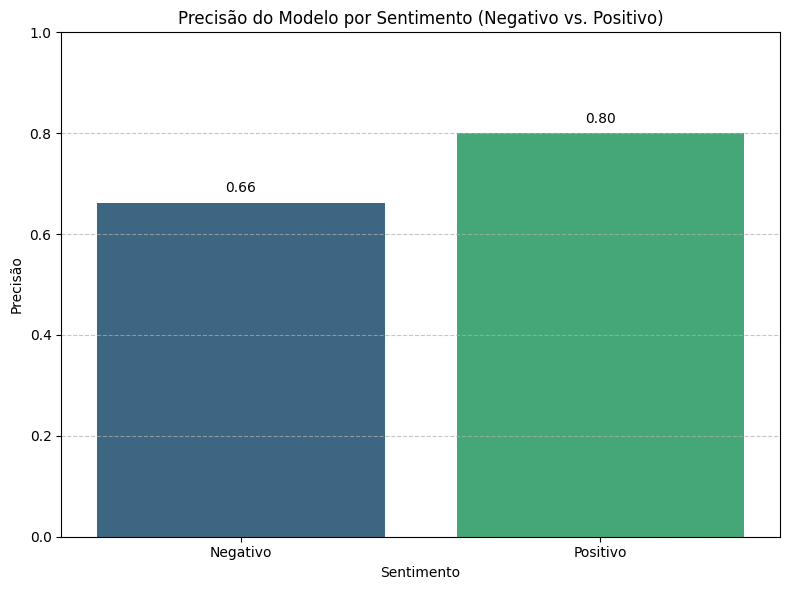

In [ ]:
from sklearn.metrics import classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Gera o relatório de classificação e extrai as precisões.
report_dict = classification_report(df['Positive'], df['sentiment'], output_dict=True)
precision_negative = report_dict['0']['precision']
precision_positive = report_dict['1']['precision']

# Cria DataFrame para visualização.
data = {
    'Sentimento': ['Negativo', 'Positivo'],
    'Precisão': [precision_negative, precision_positive]
}
accuracy_df = pd.DataFrame(data)

# Gera o gráfico de barras da precisão por sentimento.
plt.figure(figsize=(8, 6))
sns.barplot(x='Sentimento', y='Precisão', data=accuracy_df, palette='viridis')
plt.title('Precisão do Modelo por Sentimento (Negativo vs. Positivo)')
plt.xlabel('Sentimento')
plt.ylabel('Precisão')
plt.ylim(0, 1)

# Adiciona valores nas barras.
for index, row in accuracy_df.iterrows():
    plt.text(index, row['Precisão'] + 0.02, f'{row['Precisão']:.2f}', color='black', ha="center")

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import accuracy_score

# Calcula a acurácia global do modelo.
# Compara os rótulos verdadeiros ('Positive') com as previsões do modelo ('sentiment').
global_accuracy = accuracy_score(df['Positive'], df['sentiment'])

print(f"Acurácia Global do Modelo: {global_accuracy:.2f}")

Acurácia Global do Modelo: 0.79
